# Rede de Vulnerabilidades Socioeconômicas nas regiões metropolitanas do Brasil

# 1. Coleta, limpeza e tratamento dos dados

## 1.1 Instalando e carregando os pacotes necessários

In [ ]:
# Instalando e carregando as bibliotecas necessárias
if (!requireNamespace("bigrquery", quietly = TRUE)) {
  install.packages("bigrquery")
}
if (!requireNamespace("dplyr", quietly = TRUE)) {
  install.packages("dplyr")
}

Instalando pacote em 'C:/Users/mauri/AppData/Local/R/win-library/4.5'
(como 'lib' não foi especificado)

instalando as dependências 'brio', 'clock', 'nanoparquet', 'rapidjsonr' também




pacote 'brio' desempacotado com sucesso e somas MD5 verificadas
pacote 'clock' desempacotado com sucesso e somas MD5 verificadas
pacote 'nanoparquet' desempacotado com sucesso e somas MD5 verificadas
pacote 'rapidjsonr' desempacotado com sucesso e somas MD5 verificadas
pacote 'bigrquery' desempacotado com sucesso e somas MD5 verificadas

Os pacotes binários baixados estão em
	C:\Users\mauri\AppData\Local\Temp\RtmpoJkb7m\downloaded_packages


In [ ]:
# Instalando o pacote plm
install.packages("plm")

Instalando pacote em 'C:/Users/mauri/AppData/Local/R/win-library/4.5'
(como 'lib' não foi especificado)

instalando as dependências 'miscTools', 'rbibutils', 'bdsmatrix', 'collapse', 'zoo', 'sandwich', 'lmtest', 'maxLik', 'Rdpack', 'Formula' também




pacote 'miscTools' desempacotado com sucesso e somas MD5 verificadas
pacote 'rbibutils' desempacotado com sucesso e somas MD5 verificadas
pacote 'bdsmatrix' desempacotado com sucesso e somas MD5 verificadas
pacote 'collapse' desempacotado com sucesso e somas MD5 verificadas
pacote 'zoo' desempacotado com sucesso e somas MD5 verificadas
pacote 'sandwich' desempacotado com sucesso e somas MD5 verificadas
pacote 'lmtest' desempacotado com sucesso e somas MD5 verificadas
pacote 'maxLik' desempacotado com sucesso e somas MD5 verificadas
pacote 'Rdpack' desempacotado com sucesso e somas MD5 verificadas
pacote 'Formula' desempacotado com sucesso e somas MD5 verificadas
pacote 'plm' desempacotado com sucesso e somas MD5 verificadas

Os pacotes binários baixados estão em
	C:\Users\mauri\AppData\Local\Temp\RtmpoJkb7m\downloaded_packages


In [6]:
# Carregando pacotes
library(bigrquery)
library(dplyr)
library(plm)


Anexando pacote: 'plm'


Os seguintes objetos são mascarados por 'package:dplyr':

    between, lag, lead




## 1.2 Coletando os dados

In [13]:
# Configurando o caminho para a chave de autenticação
json_key_path <- "C:/Users/mauri/OneDrive/Área de Trabalho/nuvem automatico/Área de Estudo-Trabalho/Mestrado em Economia/Disciplinas/2° Semestre de 2024/ECO 655 - Métodos Econométricos/Artigo/Dados_Painel/pnad-pseudo-painel-853c2b9ebce4.json"

# Autenticando o BigQuery usando a chave de serviço
bq_auth(path = json_key_path)

# Configurando o projeto
project_id <- "pnad-pseudo-painel"

# Especificando a consulta SQL
query <- "
WITH dicionario AS (
  SELECT DISTINCT nome_coluna, chave, valor
  FROM `basedosdados.br_ibge_pnadc.dicionario`
),
tabela_base AS (
  SELECT
    ano,                                    
    trimestre,                              
    id_uf AS unidade_federacao,             
    rm_ride AS regiao_metropolitana,        
    capital AS municipio_capital,           
    VD4016 AS rendimento_habitual_principal, 
    VD4017 / V2001 AS rendimento_domiciliar_pc, 
    V2001 AS numero_pessoas_domicilio,      
    VD3005 AS anos_estudo,      
    V3001 AS sabe_ler_escrever,             
    V2009 AS idade,                         
    V2007 AS sexo,                          
    V2010 AS cor_raca,                      
    VD4001 AS condicao_ocupacao,            
    posest,                                 
    posest_sxi,                             
    SAFE_DIVIDE(
      SUM(CASE 
            WHEN V3001 = '2' AND V2009 >= 15 THEN 1
            ELSE 0 
          END) 
      OVER (PARTITION BY ano, trimestre, rm_ride),
      SUM(CASE 
            WHEN V2009 >= 15 THEN 1
            ELSE 0 
          END) 
      OVER (PARTITION BY ano, trimestre, rm_ride)
    ) AS taxa_analfabetismo
  FROM
    `basedosdados.br_ibge_pnadc.microdados`
  WHERE
    rm_ride IS NOT NULL                     
    AND ano BETWEEN 2013 AND 2023           
    AND VD4016 IS NOT NULL                  
    AND VD4017 IS NOT NULL                  
    AND V2001 IS NOT NULL                   
    AND VD3005 IS NOT NULL                  
    AND VD4001 IS NOT NULL                  
    AND V3001 IS NOT NULL                   
    AND V2009 IS NOT NULL                   
    AND V2007 IS NOT NULL                   
    AND V2010 IS NOT NULL                   
),
tabela_substituida AS (
  SELECT
    b.ano,
    b.trimestre,
    COALESCE(d_uf.valor, CAST(b.unidade_federacao AS STRING)) AS unidade_federacao_nome,
    COALESCE(d_rm.valor, CAST(b.regiao_metropolitana AS STRING)) AS regiao_metropolitana_nome,
    COALESCE(d_cap.valor, CAST(b.municipio_capital AS STRING)) AS municipio_capital_nome,
    b.rendimento_habitual_principal,
    b.rendimento_domiciliar_pc,
    b.numero_pessoas_domicilio,
    b.anos_estudo,
    COALESCE(d_escrever.valor, CAST(b.sabe_ler_escrever AS STRING)) AS sabe_ler_escrever_nome,
    b.idade,
    COALESCE(d_sexo.valor, CAST(b.sexo AS STRING)) AS sexo_nome,
    COALESCE(d_raca.valor, CAST(b.cor_raca AS STRING)) AS cor_raca_nome,
    COALESCE(d_ocupacao.valor, CAST(b.condicao_ocupacao AS STRING)) AS condicao_ocupacao_nome,
    b.posest,
    b.posest_sxi,
    b.taxa_analfabetismo
  FROM
    tabela_base b
  LEFT JOIN dicionario d_uf ON d_uf.nome_coluna = 'id_uf' AND d_uf.chave = CAST(b.unidade_federacao AS STRING)
  LEFT JOIN dicionario d_rm ON d_rm.nome_coluna = 'rm_ride' AND d_rm.chave = CAST(b.regiao_metropolitana AS STRING)
  LEFT JOIN dicionario d_cap ON d_cap.nome_coluna = 'capital' AND d_cap.chave = CAST(b.municipio_capital AS STRING)
  LEFT JOIN dicionario d_escrever ON d_escrever.nome_coluna = 'V3001' AND d_escrever.chave = CAST(b.sabe_ler_escrever AS STRING)
  LEFT JOIN dicionario d_sexo ON d_sexo.nome_coluna = 'V2007' AND d_sexo.chave = CAST(b.sexo AS STRING)
  LEFT JOIN dicionario d_raca ON d_raca.nome_coluna = 'V2010' AND d_raca.chave = CAST(b.cor_raca AS STRING)
  LEFT JOIN dicionario d_ocupacao ON d_ocupacao.nome_coluna = 'VD4001' AND d_ocupacao.chave = CAST(b.condicao_ocupacao AS STRING)
)
SELECT * FROM tabela_substituida
ORDER BY regiao_metropolitana_nome, ano, trimestre
"

# Executando a consulta no BigQuery
result <- bq_table_download(bq_project_query(project_id, query))

# Verificando os primeiros 15 registros dos dados
head(result, 15)


ano,trimestre,unidade_federacao_nome,regiao_metropolitana_nome,municipio_capital_nome,rendimento_habitual_principal,rendimento_domiciliar_pc,numero_pessoas_domicilio,anos_estudo,sabe_ler_escrever_nome,idade,sexo_nome,cor_raca_nome,condicao_ocupacao_nome,posest,posest_sxi,taxa_analfabetismo
<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
2013,1,22,Região Administrativa Integrada de Desenvolvimento da Grande Teresina (PI),NA,1200,400.0000,3,12,Sim,27,Mulher,Parda,Pessoas na força de trabalho,223,206,0.08405439
2013,1,22,Região Administrativa Integrada de Desenvolvimento da Grande Teresina (PI),Município de Teresina (PI),1244,311.0000,4,12,Sim,45,Mulher,Preta,Pessoas na força de trabalho,221,210,0.08405439
2013,1,22,Região Administrativa Integrada de Desenvolvimento da Grande Teresina (PI),Município de Teresina (PI),650,170.0000,5,14,Sim,28,Mulher,Preta,Pessoas na força de trabalho,221,206,0.08405439
2013,1,22,Região Administrativa Integrada de Desenvolvimento da Grande Teresina (PI),Município de Teresina (PI),622,311.0000,2,14,Sim,20,Mulher,Branca,Pessoas na força de trabalho,221,205,0.08405439
2013,1,22,Região Administrativa Integrada de Desenvolvimento da Grande Teresina (PI),NA,2500,1233.3333,3,16,Sim,58,Mulher,Parda,Pessoas na força de trabalho,223,212,0.08405439
2013,1,22,Região Administrativa Integrada de Desenvolvimento da Grande Teresina (PI),Município de Teresina (PI),840,210.0000,4,12,Sim,21,Homem,Parda,Pessoas na força de trabalho,221,105,0.08405439
2013,1,22,Região Administrativa Integrada de Desenvolvimento da Grande Teresina (PI),Município de Teresina (PI),720,144.0000,5,12,Sim,23,Homem,Parda,Pessoas na força de trabalho,221,105,0.08405439
2013,1,22,Região Administrativa Integrada de Desenvolvimento da Grande Teresina (PI),Município de Teresina (PI),622,207.3333,6,12,Sim,37,Homem,Parda,Pessoas na força de trabalho,221,108,0.08405439
2013,1,22,Região Administrativa Integrada de Desenvolvimento da Grande Teresina (PI),NA,60,15.0000,4,4,Sim,51,Homem,Parda,Pessoas na força de trabalho,223,111,0.08405439


## 1.3 Análise explorátoria inicial

### <> Nome das colunas

In [14]:
names(result)

[1] "ano"                           "trimestre"                    
 [3] "unidade_federacao_nome"        "regiao_metropolitana_nome"    
 [5] "municipio_capital_nome"        "rendimento_habitual_principal"
 [7] "rendimento_domiciliar_pc"      "numero_pessoas_domicilio"     
 [9] "anos_estudo"                   "sabe_ler_escrever_nome"       
[11] "idade"                         "sexo_nome"                    
[13] "cor_raca_nome"                 "condicao_ocupacao_nome"       
[15] "posest"                        "posest_sxi"                   
[17] "taxa_analfabetismo"

### <> Tipos de dados

In [20]:
library(dplyr)

tipos_variaveis <- tibble(
  Variavel = names(result),
  Tipo = sapply(result, class)
)

tipos_variaveis

Variavel,Tipo
<chr>,<chr>
ano,integer
trimestre,integer
unidade_federacao_nome,character
regiao_metropolitana_nome,character
municipio_capital_nome,character
rendimento_habitual_principal,numeric
rendimento_domiciliar_pc,numeric
numero_pessoas_domicilio,integer
anos_estudo,integer


### <> Verificando existência de valores nulos

In [21]:
library(dplyr)

tabela_nulos <- tibble(
  Variavel = names(result),
  Quantidade_Nulos = sapply(result, function(x) sum(is.na(x))),
  Porcentagem = round(
    100 * sapply(result, function(x) sum(is.na(x))) / nrow(result),
    2
  )
) %>%
  arrange(desc(Quantidade_Nulos))

tabela_nulos


Variavel,Quantidade_Nulos,Porcentagem
<chr>,<int>,<dbl>
municipio_capital_nome,1253293,40.06
ano,0,0.00
trimestre,0,0.00
unidade_federacao_nome,0,0.00
regiao_metropolitana_nome,0,0.00
rendimento_habitual_principal,0,0.00
rendimento_domiciliar_pc,0,0.00
numero_pessoas_domicilio,0,0.00
anos_estudo,0,0.00


## 1.4 Limpeza e Tratamento dos dados

In [23]:
# =========================
# TRATAMENTOS (R) -> BASE FINAL: dados_pnad
# =========================

library(dplyr)
library(stringr)

# 1) Padronização de tipos + criação de variável auxiliar de capital
dados_pnad <- result %>%
  mutate(
    # Garantindo inteiros
    ano = as.integer(ano),
    trimestre = as.integer(trimestre),
    numero_pessoas_domicilio = as.integer(numero_pessoas_domicilio),
    anos_estudo = as.integer(anos_estudo),
    idade = as.integer(idade),

    # Algumas colunas vieram como texto
    unidade_federacao_nome = suppressWarnings(as.integer(unidade_federacao_nome)),
    posest = suppressWarnings(as.integer(posest)),
    posest_sxi = suppressWarnings(as.integer(posest_sxi)),

    # Indicador de capital (1 se tem nome de capital, 0 se NA)
    eh_capital = ifelse(is.na(municipio_capital_nome), 0L, 1L),

    # Normalização simples de textos (evita variações com espaços)
    regiao_metropolitana_nome = str_squish(regiao_metropolitana_nome),
    sabe_ler_escrever_nome = str_squish(sabe_ler_escrever_nome),
    sexo_nome = str_squish(sexo_nome),
    cor_raca_nome = str_squish(cor_raca_nome),
    condicao_ocupacao_nome = str_squish(condicao_ocupacao_nome)
  )

# 2) Discretizações (para ARS de vulnerabilidades) + dummies úteis
dados_pnad <- dados_pnad %>%
  mutate(
    # Alfabetização (dummy)
    analfabeto = ifelse(tolower(sabe_ler_escrever_nome) %in% c("não", "nao"), 1L, 0L),

    # Faixas de idade
    faixa_idade = case_when(
      is.na(idade) ~ NA_character_,
      idade < 18 ~ "<18",
      idade <= 29 ~ "18-29",
      idade <= 44 ~ "30-44",
      idade <= 59 ~ "45-59",
      TRUE ~ "60+"
    ),

    # Escolaridade em níveis
    escolaridade_nivel = case_when(
      is.na(anos_estudo) ~ NA_character_,
      anos_estudo <= 4 ~ "Baixa",
      anos_estudo <= 11 ~ "Média",
      TRUE ~ "Alta"
    ),

    # Renda domiciliar per capita em quintis
    renda_pc_quintil = ifelse(
      is.na(rendimento_domiciliar_pc),
      NA_character_,
      as.character(ntile(rendimento_domiciliar_pc, 5))
    ),

    # Renda habitual principal em quintis
    renda_princ_quintil = ifelse(
      is.na(rendimento_habitual_principal),
      NA_character_,
      as.character(ntile(rendimento_habitual_principal, 5))
    ),

    # Dummies de vulnerabilidade
    renda_pc_baixa = ifelse(!is.na(renda_pc_quintil) & renda_pc_quintil == "1", 1L, 0L),
    baixa_escolaridade = ifelse(escolaridade_nivel == "Baixa", 1L, 0L),
    vulneravel_idoso = ifelse(!is.na(idade) & idade >= 60, 1L, 0L),

    # Dummies demográficas
    mulher = ifelse(sexo_nome == "Mulher", 1L, 0L),
    raca_preta = ifelse(cor_raca_nome == "Preta", 1L, 0L),
    raca_parda = ifelse(cor_raca_nome == "Parda", 1L, 0L),
    raca_branca = ifelse(cor_raca_nome == "Branca", 1L, 0L)
  ) %>%
  # 3) (Opcional) Selecionar colunas “ARS-ready” (mantendo também as originais principais)
  select(
    ano, trimestre,
    unidade_federacao_nome, regiao_metropolitana_nome, eh_capital,
    rendimento_habitual_principal, rendimento_domiciliar_pc,
    numero_pessoas_domicilio, anos_estudo, escolaridade_nivel,
    idade, faixa_idade,
    sabe_ler_escrever_nome, analfabeto,
    sexo_nome, mulher,
    cor_raca_nome, raca_preta, raca_parda, raca_branca,
    condicao_ocupacao_nome,
    renda_pc_quintil, renda_princ_quintil,
    renda_pc_baixa, baixa_escolaridade, vulneravel_idoso,
    posest, posest_sxi, taxa_analfabetismo
  )

# 4) Exibindo o dataframe final
head(dados_pnad, 6)

ano,trimestre,unidade_federacao_nome,regiao_metropolitana_nome,eh_capital,rendimento_habitual_principal,rendimento_domiciliar_pc,numero_pessoas_domicilio,anos_estudo,escolaridade_nivel,⋯,raca_branca,condicao_ocupacao_nome,renda_pc_quintil,renda_princ_quintil,renda_pc_baixa,baixa_escolaridade,vulneravel_idoso,posest,posest_sxi,taxa_analfabetismo
<int>,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>,<chr>,⋯,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>
2013,1,22,Região Administrativa Integrada de Desenvolvimento da Grande Teresina (PI),0,1200,400.000,3,12,Alta,⋯,0,Pessoas na força de trabalho,3,2,0,0,0,223,206,0.08405439
2013,1,22,Região Administrativa Integrada de Desenvolvimento da Grande Teresina (PI),1,1244,311.000,4,12,Alta,⋯,0,Pessoas na força de trabalho,2,3,0,0,0,221,210,0.08405439
2013,1,22,Região Administrativa Integrada de Desenvolvimento da Grande Teresina (PI),1,650,170.000,5,14,Alta,⋯,0,Pessoas na força de trabalho,1,1,1,0,0,221,206,0.08405439
2013,1,22,Região Administrativa Integrada de Desenvolvimento da Grande Teresina (PI),1,622,311.000,2,14,Alta,⋯,1,Pessoas na força de trabalho,2,1,0,0,0,221,205,0.08405439
2013,1,22,Região Administrativa Integrada de Desenvolvimento da Grande Teresina (PI),0,2500,1233.333,3,16,Alta,⋯,0,Pessoas na força de trabalho,5,4,0,0,0,223,212,0.08405439
2013,1,22,Região Administrativa Integrada de Desenvolvimento da Grande Teresina (PI),1,840,210.000,4,12,Alta,⋯,0,Pessoas na força de trabalho,2,2,0,0,0,221,105,0.08405439


### <> Tipos de dados da base de dados final

In [24]:
library(dplyr)

tipos_variaveis_1 <- tibble(
  Variavel = names(dados_pnad),
  Tipo = sapply(dados_pnad, class)
)

tipos_variaveis_1

Variavel,Tipo
<chr>,<chr>
ano,integer
trimestre,integer
unidade_federacao_nome,integer
regiao_metropolitana_nome,character
eh_capital,integer
rendimento_habitual_principal,numeric
rendimento_domiciliar_pc,numeric
numero_pessoas_domicilio,integer
anos_estudo,integer


# 2. Rede de Vulnerabilidades Socioeconômicas das regiões metropolitanas do Brasil  (PNAD Contínua)

## 2.1 Definição dos nós e das vulnerabilidades (especificação do modelo relacional)

* **Objetivo:** Selecionar quais atributos serão tratados como vulnerabilidades e convertê-los em nós da rede.

In [25]:
# Carregando bibliotecas necessárias

# library(dplyr)
# library(tidyr)

# Conjunto de variáveis (nós) que formarão a rede de vulnerabilidades
vars_vulner <- c(
  "analfabeto",
  "baixa_escolaridade",
  "renda_pc_baixa",
  "vulneravel_idoso",
  "mulher",
  "raca_preta",
  "raca_parda",
  "eh_capital"
)

# Checagem rápida de presença e distribuição
stopifnot(all(vars_vulner %in% names(dados_pnad)))

dados_pnad %>%
  select(all_of(vars_vulner)) %>%
  summarise(across(everything(), ~ mean(.x, na.rm = TRUE))) %>%
  t()

analfabeto,0.02009408
baixa_escolaridade,0.06128210
renda_pc_baixa,0.20000013
vulneravel_idoso,0.07808545
mulher,0.44878620
raca_preta,0.10765697
raca_parda,0.47931378
eh_capital,0.59939274


Neste estudo, os nós da rede representam condições de vulnerabilidade socioeconômica e características demográficas associadas à exclusão social. A escolha dos nós buscou capturar dimensões centrais da vulnerabilidade no contexto urbano-metropolitano brasileiro.

As proporções médias observadas indicam:

* **Alta incidência de atributos demográficos:**

> raca_parda (≈ 48%) e mulher (≈ 45%) apresentam elevada prevalência, refletindo a composição sociodemográfica da população metropolitana.

* **Vulnerabilidades econômicas relevantes:**

> renda_pc_baixa atinge cerca de 20% dos indivíduos, evidenciando a persistência de restrições econômicas mesmo em áreas metropolitanas.

* **Vulnerabilidades estruturais específicas:**

> baixa_escolaridade (≈ 6%) e analfabeto (≈ 2%) aparecem com menor prevalência, mas são socialmente relevantes por seu forte impacto cumulativo.

* **Dimensão territorial:**

> eh_capital (≈ 60%) destaca a forte concentração populacional nas capitais e regiões centrais das metrópoles.

> Esse conjunto de nós permite analisar a arquitetura relacional das vulnerabilidades, indo além de análises isoladas de frequência.

## 2.2 Construção da matriz binária (domicílio/pessoa × vulnerabilidade)

* **Objetivo:** Transformar a base em formato adequado para coocorrência.

In [31]:
# Carregando bibliotecas
library(dplyr)
library(tidyr)
library(Matrix)

dados_ars <- dados_pnad %>%
  mutate(id_obs = row_number()) %>%
  select(id_obs, all_of(vars_vulner)) %>%
  drop_na()

X <- as.matrix(dados_ars %>% select(all_of(vars_vulner)))
Xs <- Matrix(X, sparse = TRUE)


Anexando pacote: 'tidyr'


Os seguintes objetos são mascarados por 'package:Matrix':

    expand, pack, unpack




> A matriz binária foi construída atribuindo valor 1 quando o indivíduo apresenta determinada vulnerabilidade e 0 caso contrário.

> Essa etapa transforma a base microdados em um formato adequado para Análise de Redes Sociais, permitindo:

* mensurar coocorrência de vulnerabilidades;

* preservar a estrutura de grande escala da PNAD Contínua;

* viabilizar o uso de matrizes esparsas, evitando problemas de memória.

## 2.3 Construção da rede de coocorrência (vulnerabilidade ↔ vulnerabilidade)

* **Objetivo**: Criar a rede ponderada a partir de X'X (coocorrência).

In [32]:
# Carregando bibliotecas
library(igraph)

# Coocorrência entre vulnerabilidades: A = t(X) %*% X
A <- Matrix::crossprod(Xs)
diag(A) <- 0

A_dense <- as.matrix(A)
colnames(A_dense) <- vars_vulner
rownames(A_dense) <- vars_vulner

# Convertendo em lista de arestas (mantendo apenas acima de um corte)
min_weight <- 5000  # pode ser ajustado conforme densidade
inds <- which(A_dense >= min_weight, arr.ind = TRUE)

edges <- data.frame(
  from = rownames(A_dense)[inds[,1]],
  to   = colnames(A_dense)[inds[,2]],
  weight = A_dense[inds]
) %>%
  filter(from < to)

g_vulner <- graph_from_data_frame(edges, directed = FALSE, vertices = data.frame(name = vars_vulner))
E(g_vulner)$weight <- edges$weight

g_vulner


Anexando pacote: 'igraph'


O seguinte objeto é mascarado por 'package:tidyr':

    crossing


Os seguintes objetos são mascarados por 'package:dplyr':

    as_data_frame, groups, union


Os seguintes objetos são mascarados por 'package:stats':

    decompose, spectrum


O seguinte objeto é mascarado por 'package:base':

    union




IGRAPH c63862b UNW- 8 27 -- 
+ attr: name (v/c), weight (e/n)
+ edges from c63862b (vertex names):
 [1] analfabeto        --baixa_escolaridade
 [2] analfabeto        --renda_pc_baixa    
 [3] baixa_escolaridade--renda_pc_baixa    
 [4] renda_pc_baixa    --mulher            
 [5] renda_pc_baixa    --raca_preta        
 [6] renda_pc_baixa    --raca_parda        
 [7] renda_pc_baixa    --eh_capital        
 [8] analfabeto        --vulneravel_idoso  
+ ... omitted several edges

> A rede de coocorrência foi obtida a partir do produto X'X, resultando em uma rede não direcionada e ponderada, onde:

* nós = tipos de vulnerabilidade;

* arestas = número de indivíduos que apresentam simultaneamente duas vulnerabilidades.

> Características gerais da rede:

* 8 nós

* 27 arestas

* Rede praticamente completa, indicando que a maioria das vulnerabilidades coocorre de forma sistemática.

> As ligações observadas mostram que:

* renda_pc_baixa ocupa posição central, conectando-se fortemente a variáveis demográficas (mulher, raca_parda, raca_preta) e territoriais (eh_capital);

* vulnerabilidades educacionais (analfabeto, baixa_escolaridade) aparecem conectadas, mas com menor peso relativo, sugerindo que atuam como fatores estruturais mais específicos.

## 2.4 Métricas de Análise de Redes Sociais (ARS)

* **Objetivo:** Quantificar estrutura e identificar vulnerabilidades centrais.

### <> Métricas estruturais globais da rede

In [33]:
# Distância inversa do peso para betweenness
E(g_vulner)$dist <- 1 / E(g_vulner)$weight

metricas_rede <- data.frame(
  nodes = vcount(g_vulner),
  edges = gsize(g_vulner),
  density = edge_density(g_vulner),
  components = components(g_vulner)$no,
  modularity_louvain = modularity(cluster_louvain(g_vulner, weights = E(g_vulner)$weight))
)

metricas_rede

nodes,edges,density,components,modularity_louvain
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
8,27,0.9642857,1,0.0192267


Os principais indicadores estruturais apontam:

* Alta densidade (0,96)
> → a rede é fortemente conectada, indicando que as vulnerabilidades raramente ocorrem de forma isolada.

* Um único componente conexo
> → todas as vulnerabilidades fazem parte de um mesmo sistema relacional.

* Baixa modularidade (≈ 0,02)
> → não há comunidades bem definidas; as vulnerabilidades se organizam em um bloco integrado, e não em grupos isolados.

Esse resultado sugere que, no contexto metropolitano, a vulnerabilidade social é multidimensional e interdependente.

### <> Centralidades (ranking de nós mais importantes)

In [34]:
centralidades <- data.frame(
  node = V(g_vulner)$name,
  strength = strength(g_vulner, weights = E(g_vulner)$weight),
  betweenness = betweenness(g_vulner, weights = E(g_vulner)$dist, normalized = TRUE),
  eigenvector = eigen_centrality(g_vulner, weights = E(g_vulner)$weight)$vector
) %>%
  arrange(desc(strength))

head(centralidades, 10)

,node,strength,betweenness,eigenvector
,<chr>,<dbl>,<dbl>,<dbl>
eh_capital,eh_capital,2566554,0.5238095,1.00000000
mulher,mulher,2175254,0.0000000,0.91044795
raca_parda,raca_parda,2166301,0.4761905,0.91709199
renda_pc_baixa,renda_pc_baixa,1287402,0.0000000,0.55258054
raca_preta,raca_preta,480437,0.0000000,0.20450040
baixa_escolaridade,baixa_escolaridade,478016,0.0000000,0.16898050
vulneravel_idoso,vulneravel_idoso,475993,0.0000000,0.19925432
analfabeto,analfabeto,207067,0.0000000,0.06216279


A análise de centralidade revela papéis distintos entre as vulnerabilidades:

> → Centralidade de força (strength)

* eh_capital apresenta a maior força, indicando que a condição territorial está fortemente associada às demais vulnerabilidades.

* mulher e raca_parda também exibem elevada força, reforçando o caráter estrutural das desigualdades de gênero e raça.

> → Centralidade de intermediação (betweenness)

* eh_capital e raca_parda possuem valores positivos, atuando como nós-ponte na rede.

* Isso sugere que a localização territorial e a raça/cor conectam diferentes dimensões da vulnerabilidade.

> → Centralidade de autovetor (eigenvector)

* eh_capital apresenta valor máximo (1.0), indicando que está conectado a outros nós altamente centrais.

* mulher e raca_parda também possuem altos valores, reforçando seu papel como núcleo da rede de vulnerabilidades.

Já variáveis como analfabeto e baixa_escolaridade apresentam menor centralidade, atuando como vulnerabilidades mais periféricas, porém ainda integradas ao sistema.

## 2.5 Visualização e interpretação da rede

### <> Visualização ponderada (peso e rótulo)

Carregando pacotes exigidos: ggplot2

Warning message:
"The `trans` argument of `continuous_scale()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `transform` argument instead."


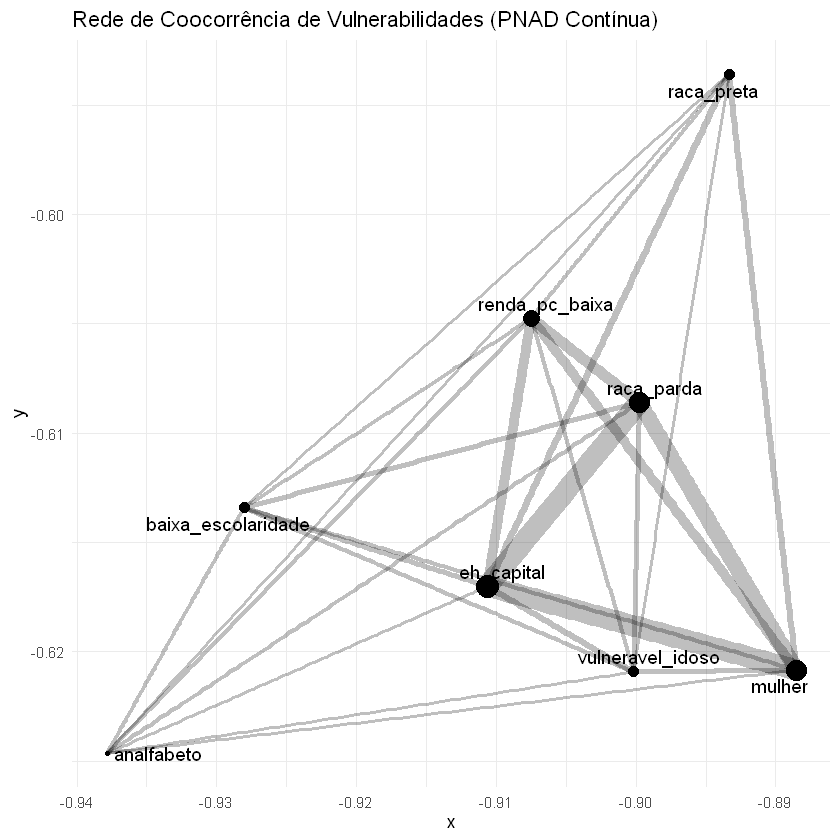

In [35]:
library(ggraph)
library(ggplot2)

set.seed(123)

ggraph(g_vulner, layout = "fr") +
  geom_edge_link(aes(width = weight), alpha = 0.25) +
  geom_node_point(aes(size = strength(g_vulner, weights = E(g_vulner)$weight))) +
  geom_node_text(aes(label = name), repel = TRUE, size = 4) +
  theme_minimal() +
  guides(edge_width = "none", size = "none") +
  labs(title = "Rede de Coocorrência de Vulnerabilidades (PNAD Contínua)")

> → Estrutura geral da rede

A visualização da rede de coocorrência evidencia uma estrutura altamente conectada, coerente com as métricas apresentadas anteriormente (alta densidade e único componente). Todas as vulnerabilidades estão interligadas, indicando que, no contexto metropolitano brasileiro, as desvantagens sociais tendem a se acumular.

> → Núcleo central da rede

Observa-se um núcleo bem definido formado principalmente por:

* eh_capital

* mulher

* raca_parda

* renda_pc_baixa

> → Esses nós apresentam:

* maior tamanho (maior força),

* maior proximidade espacial,

* e arestas mais espessas, indicando elevada coocorrência.

Esse núcleo sugere que a vulnerabilidade econômica (renda_pc_baixa) está fortemente associada a características demográficas e territoriais, funcionando como elemento articulador da rede.

> → Vulnerabilidades periféricas, porém integradas

As variáveis:

* analfabeto

* baixa_escolaridade

* vulneravel_idoso

aparecem mais afastadas do centro visual da rede, com menor tamanho relativo. Contudo, elas permanecem conectadas a todos os demais nós, indicando que:

* são menos frequentes,

* mas não são isoladas,

* e se manifestam conjuntamente com outras vulnerabilidades centrais.

> → Papel da dimensão racial

A posição de raca_preta e raca_parda evidencia que a dimensão racial está:

* fortemente conectada à renda,

* associada ao gênero,

* e integrada ao eixo territorial.

Isso reforça a interpretação de que desigualdades raciais atuam como fatores estruturantes da vulnerabilidade socioeconômica nas metrópoles.

### <> Comunidades (Louvain)

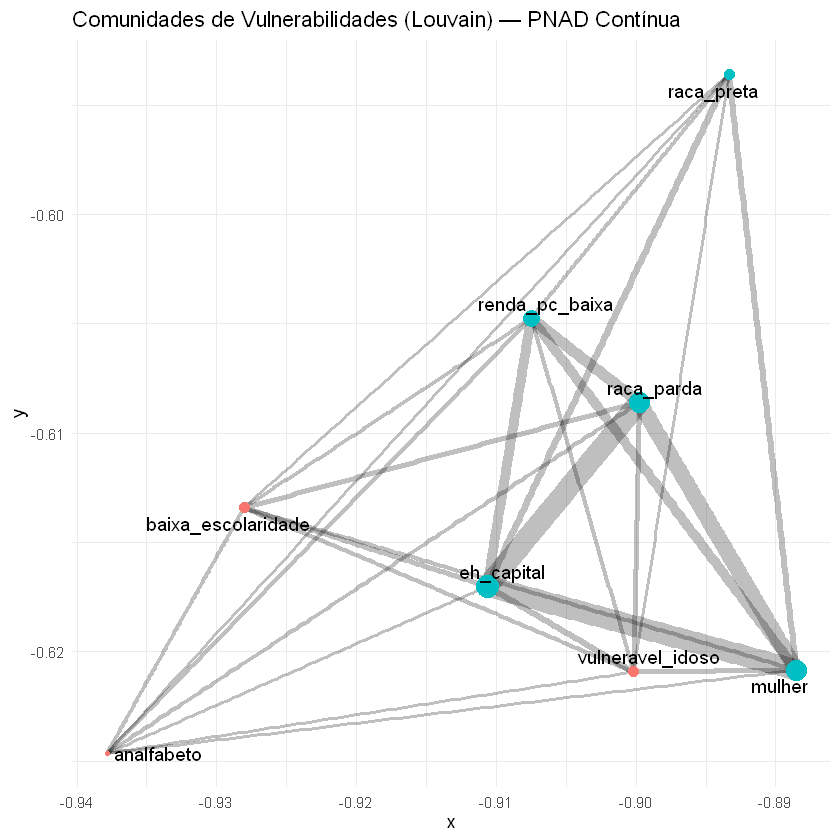

In [36]:
cl <- cluster_louvain(g_vulner, weights = E(g_vulner)$weight)
V(g_vulner)$community <- as.factor(membership(cl))

set.seed(123)

ggraph(g_vulner, layout = "fr") +
  geom_edge_link(aes(width = weight), alpha = 0.25) +
  geom_node_point(aes(color = community, size = strength(g_vulner, weights = E(g_vulner)$weight))) +
  geom_node_text(aes(label = name), repel = TRUE, size = 4) +
  theme_minimal() +
  guides(edge_width = "none", size = "none", color = "none") +
  labs(title = "Comunidades de Vulnerabilidades (Louvain) — PNAD Contínua")

> → Ausência de segmentação forte

A visualização por comunidades confirma o resultado quantitativo da baixa modularidade. Embora o algoritmo de Louvain identifique cores distintas, as fronteiras entre comunidades são pouco nítidas, indicando fraca separação estrutural.

Isso sugere que:

* não há “tipos” isolados de vulnerabilidade,

* mas sim um sistema integrado de desvantagens.

> → Pequenos agrupamentos funcionais

Mesmo sem comunidades bem definidas, é possível observar agrupamentos funcionais:

Um agrupamento mais central envolvendo:

* eh_capital,

* mulher,

* raca_parda,

* renda_pc_baixa,

que representa o núcleo urbano-demográfico da vulnerabilidade.

* Vulnerabilidades educacionais (analfabeto, baixa_escolaridade) aparecem como um subconjunto mais periférico, mas ainda fortemente conectado ao núcleo econômico.

* vulneravel_idoso atua como um nó de transição, ligando dimensões demográficas e econômicas.

> → Interpretação estrutural

A configuração das comunidades indica que a vulnerabilidade socioeconômica nas regiões metropolitanas brasileiras:

* não se organiza em blocos independentes,

* apresenta sobreposição intensa de dimensões sociais,

* e reflete um padrão de exclusão multidimensional e cumulativo.

## 2.6 Síntese e Conclusões

* Os resultados da Análise de Redes Sociais aplicada aos microdados da PNAD Contínua revelam que a vulnerabilidade socioeconômica nas regiões metropolitanas do Brasil se estrutura como um sistema altamente integrado, no qual diferentes dimensões da desigualdade se reforçam mutuamente.

* A elevada densidade da rede e a ausência de comunidades bem delimitadas indicam que as vulnerabilidades raramente se manifestam de forma isolada. Ao contrário, características econômicas, demográficas, raciais e territoriais coexistem e se articulam em um mesmo arranjo relacional.

* A centralidade da renda domiciliar per capita baixa confirma seu papel como eixo estruturante da vulnerabilidade, conectando-se fortemente a fatores como gênero, raça e localização urbana. A posição de destaque de variáveis como mulher, raca_parda e eh_capital evidencia que a exclusão socioeconômica nas metrópoles brasileiras está profundamente marcada por desigualdades estruturais, e não apenas por condições individuais.

* Vulnerabilidades educacionais e etárias, embora menos frequentes, permanecem integradas à rede, indicando que atuam como fatores adicionais de reforço da desvantagem social. Dessa forma, o padrão observado aponta para a existência de acúmulo de vulnerabilidades, o que amplia riscos sociais e limita oportunidades de mobilidade.

* Do ponto de vista metodológico, a abordagem de redes mostrou-se eficaz para capturar a arquitetura relacional da desigualdade, oferecendo uma leitura complementar às análises tradicionais. Do ponto de vista das políticas públicas, os resultados sugerem que intervenções focadas em uma única dimensão tendem a ser insuficientes, reforçando a necessidade de estratégias integradas para o enfrentamento da vulnerabilidade socioeconômica nas regiões metropolitanas do Brasil.